In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import InceptionV3, MobileNetV2
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

2026-04-02 06:23:36.833173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775111017.273990      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775111017.379986      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775111018.367737      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775111018.367786      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775111018.367789      55 computation_placer.cc:177] computation placer alr

In [3]:
augmented_dir = "/kaggle/input/datasets/marjukibnabelayet/cse438-group4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Augmented_Dataset"

original_dir = "/kaggle/input/datasets/marjukibnabelayet/cse438-group4/Comprehensive Betel Leaf Disease Dataset for Advanced Pathology Research/Betel Leaf Dataset/Betel Leaf Dataset/Betel Leaf Dataset/Original_Dataset"

In [4]:
IMG_SIZE = (299, 299)
BATCH_SIZE = 16
EPOCHS = 20
SEED = 42

AUTOTUNE = tf.data.AUTOTUNE

In [5]:
class_names = sorted([
    d for d in os.listdir(augmented_dir)
    if os.path.isdir(os.path.join(augmented_dir, d))
])

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['Healthy_Leaf', 'Leaf_Rot', 'Leaf_Spot']
Number of classes: 3


In [6]:
def get_image_paths_and_labels(data_dir, class_names):
    file_paths = []
    labels = []

    valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    for idx, class_name in enumerate(class_names):
        class_path = os.path.join(data_dir, class_name)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            if file_name.lower().endswith(valid_ext):
                file_paths.append(os.path.join(class_path, file_name))
                labels.append(idx)

    return file_paths, labels

train_paths, train_labels = get_image_paths_and_labels(augmented_dir, class_names)
original_paths, original_labels = get_image_paths_and_labels(original_dir, class_names)

print("Training images from Augmented_Dataset:", len(train_paths))
print("Images from Original_Dataset:", len(original_paths))

Training images from Augmented_Dataset: 10185
Images from Original_Dataset: 2037


In [7]:
val_paths, test_paths, val_labels, test_labels = train_test_split(
    original_paths,
    original_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=original_labels
)

print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Validation images: 1018
Test images: 1019


In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def augment_image(image, label):
    image = data_augmentation(image, training=True)
    return image, label

I0000 00:00:1775111057.587292      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775111057.593931      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [9]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def create_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [10]:
train_ds = create_dataset(train_paths, train_labels, training=True)
val_ds = create_dataset(val_paths, val_labels, training=False)
test_ds = create_dataset(test_paths, test_labels, training=False)

print("Datasets created successfully.")

Datasets created successfully.


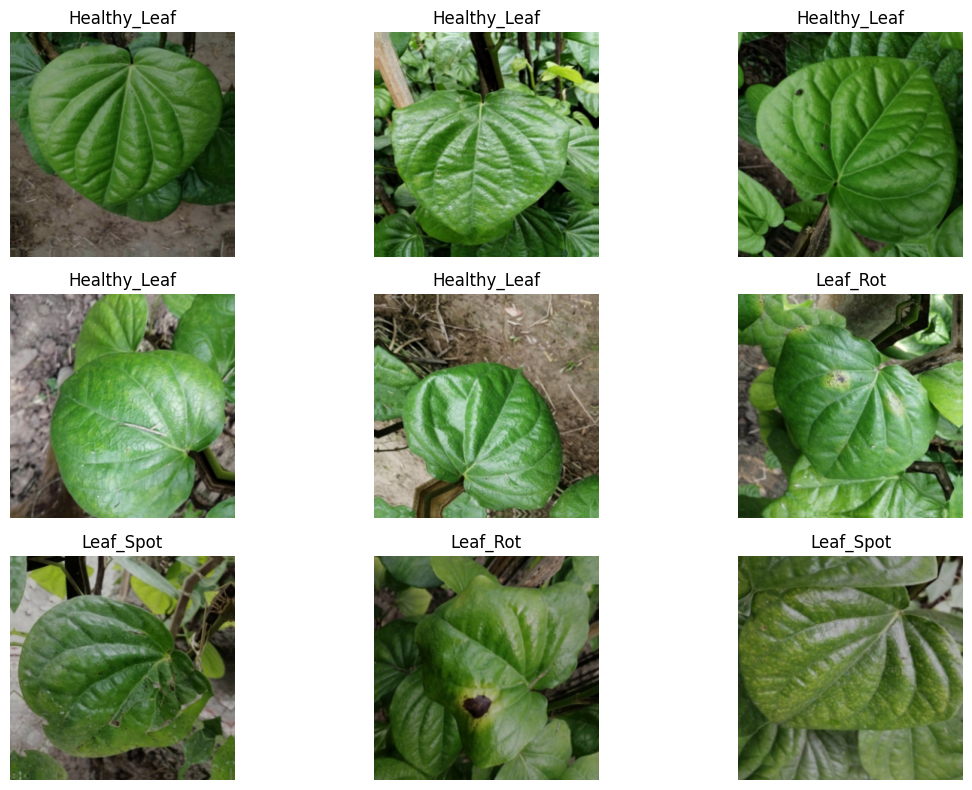

In [11]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
input_layer = layers.Input(shape=(299, 299, 3), name="input_image")

# Branch 1: InceptionV3
x1 = layers.Lambda(inception_preprocess, name="inception_preprocess")(input_layer)
inception_base = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(299, 299, 3)
)
inception_base.trainable = False
x1 = inception_base(x1, training=False)
x1 = layers.GlobalAveragePooling2D()(x1)
x1 = layers.Dense(128, activation="relu")(x1)

# Branch 2: MobileNetV2
x2 = layers.Lambda(mobilenet_preprocess, name="mobilenet_preprocess")(input_layer)
mobilenet_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(299, 299, 3)
)
mobilenet_base.trainable = False
x2 = mobilenet_base(x2, training=False)
x2 = layers.GlobalAveragePooling2D()(x2)
x2 = layers.Dense(128, activation="relu")(x2)

# Late Fusion
fusion = layers.Concatenate(name="late_fusion_concat")([x1, x2])
fusion = layers.Dense(256, activation="relu")(fusion)
fusion = layers.Dropout(0.3)(fusion)

output_layer = layers.Dense(num_classes, activation="softmax", name="output")(fusion)

model = Model(
    inputs=input_layer,
    outputs=output_layer,
    name="LateFusion_InceptionV3_MobileNetV2"
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/tmp/ipykernel_55/2732583329.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "LateFusion_InceptionV3_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_preproce… │ (None, 299, 299,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_preproce… │ (None, 299, 299,  │          0 │ input_image[0][0] │
│ (Lambda)            │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_v3        │ (None, 8, 8,      │ 21,802,784 │ inception_prepro… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 10, 10,    │  2,257,984 │ mobilenet_prepro… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ inception_v3[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ late_fusion_concat  │ (None, 256)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ late_fusion_conc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        771 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,553,571 (93.66 MB)

 Trainable params: 492,803 (1.88 MB)

 Non-trainable params: 24,060,768 (91.78 MB)

In [14]:
callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        "late_fusion_pipeline5_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20


I0000 00:00:1775111079.607849     131 service.cc:152] XLA service 0x7f05c001cf70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775111079.607895     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775111079.607900     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775111083.826911     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-02 06:24:59.422567: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 06:24:59.559167: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1775111105.199583     131 device_co

636/637 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.7518 - loss: 0.6169

2026-04-02 06:28:02.627208: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 06:28:02.765054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.7519 - loss: 0.6167

2026-04-02 06:28:44.817470: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 06:28:44.953939: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.88900, saving model to late_fusion_pipeline5_best.keras
637/637 ━━━━━━━━━━━━━━━━━━━━ 268s 355ms/step - accuracy: 0.7521 - loss: 0.6164 - val_accuracy: 0.8890 - val_loss: 0.3026 - learning_rate: 1.0000e-04
Epoch 2/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.8919 - loss: 0.3172
Epoch 2: val_accuracy improved from 0.88900 to 0.89587, saving model to late_fusion_pipeline5_best.keras
637/637 ━━━━━━━━━━━━━━━━━━━━ 153s 241ms/step - accuracy: 0.8919 - loss: 0.3172 - val_accuracy: 0.8959 - val_loss: 0.2663 - learning_rate: 1.0000e-04
Epoch 3/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9008 - loss: 0.2747
Epoch 3: val_accuracy improved from 0.89587 to 0.91356, saving model to late_fusion_pipeline5_best.keras
637/637 ━━━━━━━━━━━━━━━━━━━━ 153s 240ms/step - accuracy: 0.9009 - loss: 0.2747 - val_accuracy: 0.9136 - val_loss: 0.2367 - learning_rate: 1.0000e-04
Epoch 4/20
637/637 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy

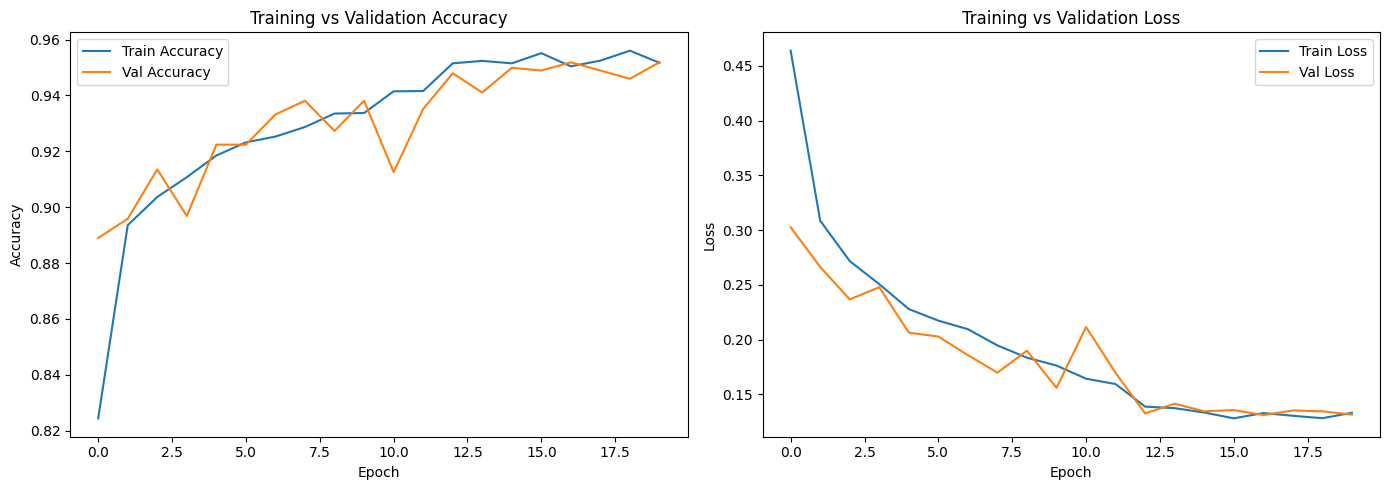

In [26]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - accuracy: 0.9558 - loss: 0.1211
Test Loss: 0.12013845145702362
Test Accuracy: 0.9578017592430115


In [28]:
y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step
              precision    recall  f1-score   support

Healthy_Leaf       0.97      0.97      0.97       540
    Leaf_Rot       0.98      0.86      0.92       135
   Leaf_Spot       0.93      0.98      0.96       344

    accuracy                           0.96      1019
   macro avg       0.96      0.94      0.95      1019
weighted avg       0.96      0.96      0.96      1019



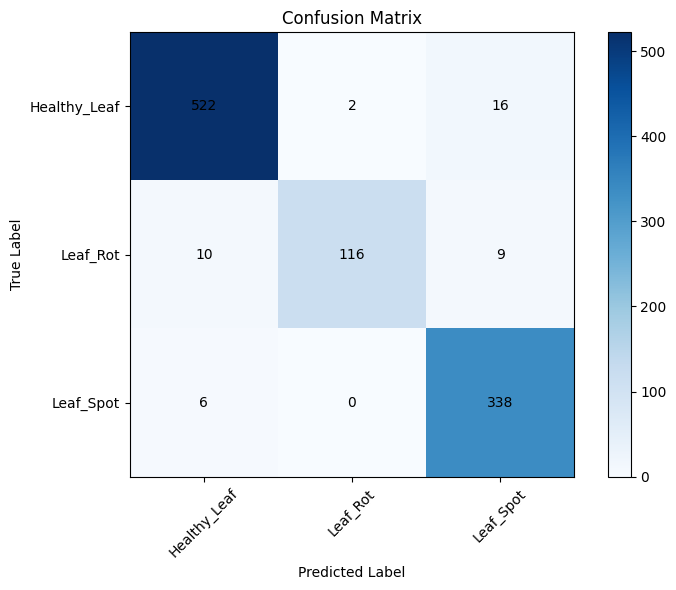

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [30]:
model.save("late_fusion_pipeline5_final.keras")
print("Model saved successfully.")

Model saved successfully.
